<a href="https://colab.research.google.com/github/ArduinoPLUS/aicar/blob/main/LinearRegOpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

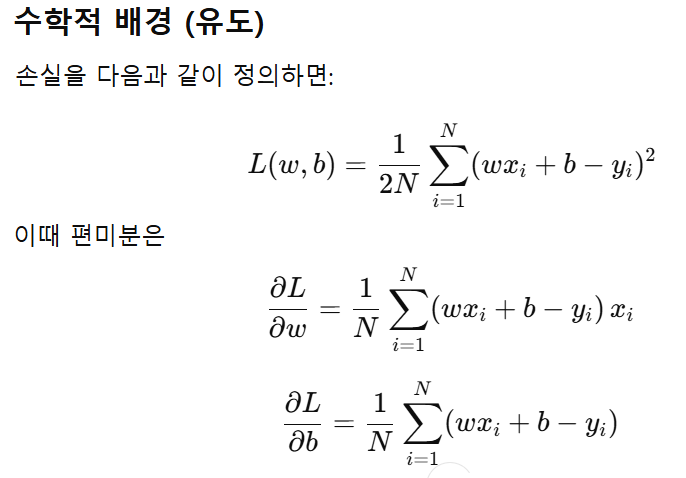

In [1]:
# 딥러닝을 위한 수치최적화 알고리즘 ---------------------- 0 <LinearRegOpt.ipynb>
import numpy as np
import matplotlib.pyplot as plt

x_train = np.array([1.0, 2.0, 3.0, 4.0, 6.0])     # X 데이터
y_train = np.array([2.0, 4.0, 3.0, 5.0, 5.0])     # Y 데이터

# 손실함수 ---------------------------------------------------------------------
def loss(w, b, x_set, y_set):
  N = len(x_set)
  val = 0.0
  for i in range(len(x_set)):
    val = val + 0.5 * ( w * x_set[i] + b - y_set[i] )**2
  return val / N                                  # scalar 값 반환

# 손실함수의 그래디언트 --------------------------------------------------------
def loss_grad(w, b, x_set, y_set):                # numpy.sum 사용
    N = len(x_set)                                # 데이터 셋의 개수
    error = (w * x_set + b) - y_set               # 오차 = 추측함수값 - 실측값
    dw = np.sum(error * x_set) / N                # ∂L/∂w
    db = np.sum(error) / N                        # ∂L/∂b
    return dw, db
'''
def loss_grad(w, b, x_set, y_set):                # for 문을 사용
  N = len(x_set)
  val_w = 0.0                                     # Initialize val_w
  val_b = 0.0                                     # Initialize val_b
  for i in range(N):
    error = w * x_set[i] + b - y_set[i]
    val_w = val_w + error * x_set[i]              # val_w = val_w + er * np.array(x_set[i])
    val_b = val_b + error                         # val_b = val_b + error * np.array(1.0)
  return (val_w/N, val_b/N)                       # vector 값 반환 [w, b]
'''
# 경로 그래프 ------------------------------------------------------------------
from matplotlib.colors import LogNorm

def contour_path(paths_w, paths_b, LEARN_RATE, ttl=' ', ax=None):
  if ax is None:
    fig, ax = plt.subplots(figsize=(8, 6))
  ax.set_xlim([-1.1, 0.82])
  ax.set_ylim([0.2, +5.5])
  ax.plot(paths_w, paths_b, 'o-')
  ax.plot(paths_w[-1],paths_b[-1], 'o-', markerfacecolor='red',markersize = 10)
  ax.set_xlabel(f'Weight(w)   Learn Rate:{LEARN_RATE}')
  ax.set_ylabel('Bias(b)')
  ax.set_title(f'{ttl}  w:{paths_w[-1]:7.4f}  b:{paths_b[-1]:7.4f}')
  ax.grid(True)

# 회귀 직선 그래프 -------------------------------------------------------------
from matplotlib.patches import Rectangle
def visualize_l2(w, b, x_train, y_train, epoch, ax=None):
  if ax is None:
    fig, ax = plt.subplots()
  ax.plot(x_train, y_train, '.k', markerfacecolor='red', markersize = 15)
  ax.plot(x_train, w * x_train + b, '--k')
  for xx,yy in zip(x_train, y_train):
    ax.add_patch(Rectangle((xx, yy), w * xx + b - yy, w * xx + b - yy, alpha=0.1,
                           facecolor='gray', edgecolor='k'))
  ax.grid()
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  # Set x-axis ticks to 1-unit intervals
  x_min_tick = int(np.floor(np.min(x_train)))
  x_max_tick = int(np.ceil(np.max(x_train)))
  ax.set_xticks(np.arange(x_min_tick, x_max_tick + 1, 1))
  # Set y-axis ticks to 1-unit intervals (considering actual and predicted y values)
  y_data_min = np.min(y_train)
  y_data_max = np.max(y_train)
  y_pred = w * x_train + b
  y_plot_min = min(y_data_min, np.min(y_pred))
  y_plot_max = max(y_data_max, np.max(y_pred))
  y_min_tick = int(np.floor(y_plot_min))
  y_max_tick = int(np.ceil(y_plot_max))
  ax.set_yticks(np.arange(max(0, y_min_tick - 1), y_max_tick + 2, 1))
  # Fixed x and y axis ranges
  ax.set_xlim([0.2, 6.8])
  ax.set_ylim([0.2, 6.8])
  ax.set_title(f'Epoch:{epoch}')

# 손실(Loss) 그래프 ------------------------------------------------------------
def loss_graph(batch_loss, loss, epoch, eff_lr_w=None, eff_lr_b=None, ax=None):
  ENLARGE = 10                          # 그래프에서 Effective Learn Rate 확대 비율
  if ax is None:
    fig, ax = plt.subplots()
  px = list(range(epoch))
  ax.plot(px, batch_loss, 'r-', lw=1, label='Loss')          # Loss
  if eff_lr_w is not None:
    eff_lr_w_x_n = [item * ENLARGE for item in eff_lr_w]     # ENLARGE 비율로 확대
    ax.plot(px, eff_lr_w_x_n, 'b-', lw=1, label=f'Eff. Learn Rate w x {ENLARGE}')
  if eff_lr_b is not None:
    eff_lr_b_x_n = [item * ENLARGE for item in eff_lr_b]     # ENLARGE 비율로 확대
    ax.plot(px, eff_lr_b_x_n, 'g-', lw=1, label=f'Eff. Learn Rate b x {ENLARGE}')
  ax.grid()
  ax.legend()
  ax.set_title(f'Epoch:{epoch}')
  ax.set_xlim([-20, 1020])
  ax.set_ylim([-0.2, 9])

#-------------------------------------------------------------------------------
def graph(TTL, epoch, w, b, LEARN_RATE, paths_w, paths_b, batch_loss,
          x_train, y_train, eff_lr_w=None, eff_lr_b=None):
  fig = plt.figure(figsize=(10, 6.66))
  gs = fig.add_gridspec(2, 2, width_ratios=[2, 1], height_ratios=[1, 1])
  # First plot (w, b graph) spanning two rows in the first column
  ax0 = fig.add_subplot(gs[:, 0])
  contour_path(paths_w, paths_b,  LEARN_RATE, f'{TTL}   Epoch:{epoch:5d}', ax=ax0)
  plt.text(-0.8, 1.1, f"{epoch}", fontdict={'size': 64})
  # Second plot (regression line) in the top right
  ax1 = fig.add_subplot(gs[0, 1])
  visualize_l2(w, b, x_train, y_train, epoch, ax=ax1)
  # Third plot (Loss graph) in the bottom right
  ax2 = fig.add_subplot(gs[1, 1])
  loss_graph(batch_loss, f'{loss(w, b, x_train, y_train):10.4f}',
             epoch, eff_lr_w, eff_lr_b, ax=ax2)
  fig.subplots_adjust(wspace=0.3, hspace=0.3)
  plt.savefig(f'{TTL}_{epoch:04d}.png')
  plt.show()


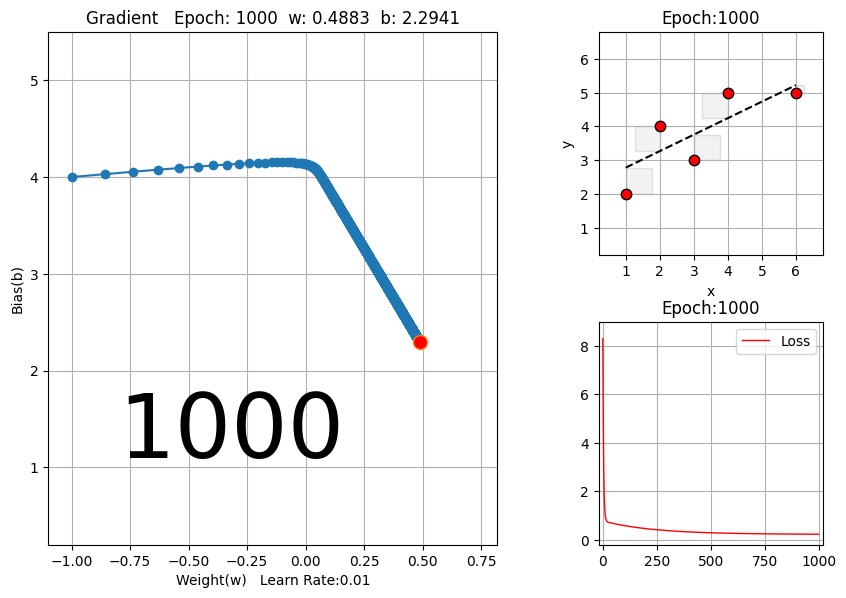

In [2]:
# Gradient Descent --------------------------------------- 1 <LinearRegOpt.ipynb>
LEARN_RATE = 0.01                                      # 학습율
MaxEpochs = 1000                                       # 반복 횟수

w = -1.0                                               # 초기값 w
b = 4.0                                                # 초기값 b

paths_w = [w,]
paths_b = [b,]
batch_loss = []

for epoch in range(MaxEpochs):                         # MaxEpochs번 반복

  u = loss(w, b, x_train, y_train)                     # 손실값 계산

  grad_w, grad_b = loss_grad(w, b, x_train, y_train)   # 그래디언트 계산

  w = w - LEARN_RATE * grad_w                             # 파라미터 업데이트
  b = b - LEARN_RATE * grad_b                             # 파라미터 업데이트

  paths_w.append(w)                                    # 시작 w 부터 저장
  paths_b.append(b)                                    # 시작 b 부터 저장
  batch_loss.append(u)                                 # 손실값 저장

graph('Gradient',epoch+1,w,b,LEARN_RATE,paths_w,paths_b,batch_loss,x_train, y_train)


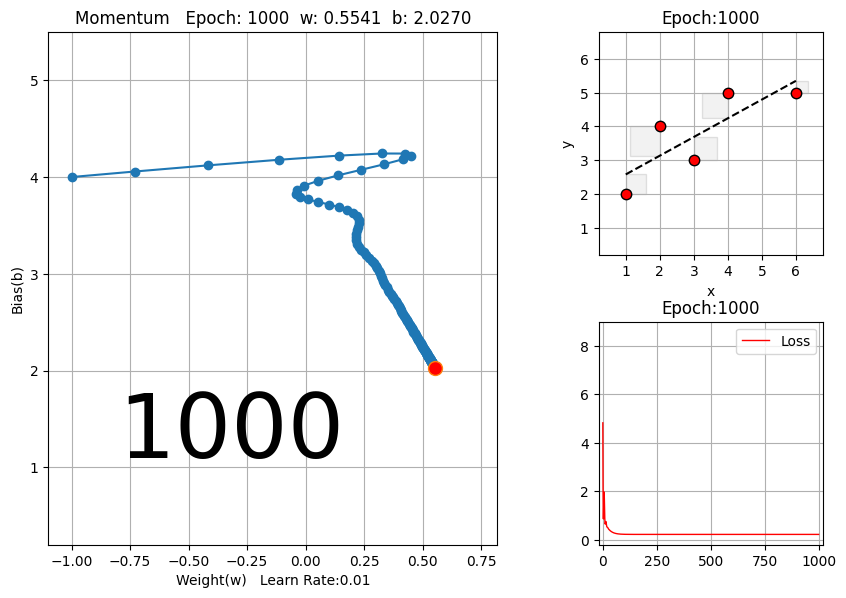

In [3]:
# Momentum ----------------------------------------------- 2 <LinearRegOpt.ipynb>
LEARN_RATE = 0.01                                    # 학습률
MaxEpochs = 1000                                     # 반복 횟수
BETA = 0.9

w = -1.0                                             # 초기값 w
b = 4.0                                              # 초기값 b

paths_w = [w,]
paths_b = [b,]
batch_loss = []

velocity_w = 0
velocity_b = 0

for epoch in range(MaxEpochs):                           # MaxEpochs번 반복

  grad_w, grad_b = loss_grad(w, b, x_train, y_train)     # 그래디언트 계산

  velocity_w = BETA * velocity_w - LEARN_RATE * grad_w   # w 탐색 방향 설정
  w = w + BETA * velocity_w - LEARN_RATE * grad_w        # w 파라메터 업데이트

  velocity_b = BETA * velocity_b - LEARN_RATE * grad_b   # b 탐색 방향 설정
  b = b + BETA * velocity_b - LEARN_RATE * grad_b        # b 파라메터 업데이트

  paths_w.append(w)
  paths_b.append(b)
  batch_loss.append(loss(w, b, x_train, y_train))

graph('Momentum',epoch+1,w,b,LEARN_RATE,paths_w,paths_b,batch_loss,x_train,y_train)


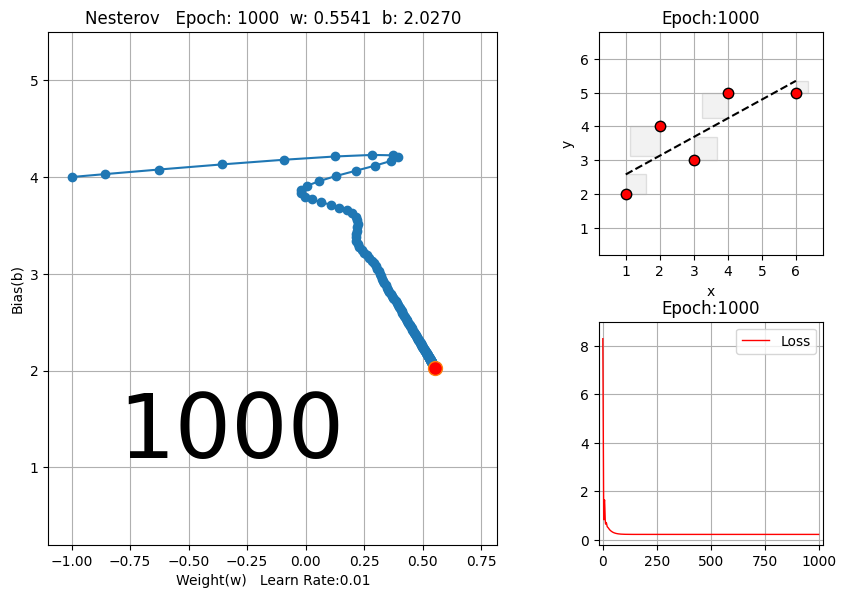

In [4]:
# Nesterov ----------------------------------------------- 3 <LinearRegOpt.ipynb>
LEARN_RATE = 0.01                                       # 학습율
MaxEpochs = 1000                                        # 반복 횟수

w = -1.0                                                # 초기값 w
b = 4.0                                                 # 초기값 b

paths_w = []
paths_b = []
batch_loss = []

alpha = 0.9

velocity_w = 0
velocity_b = 0

paths_w = []
paths_b = []

batch_loss = []

for epoch in range(MaxEpochs):                          # MaxEpochs번 반복

  paths_w.append(w)
  paths_b.append(b)
  batch_loss.append(loss(w, b, x_train, y_train))
# 그래디언트 계산
  grad_w, grad_b = loss_grad(w+alpha*velocity_w, b+alpha*velocity_b, x_train, y_train)
  LEARN_RATE = LEARN_RATE                                     # 학습률 설정

  velocity_w = alpha * velocity_w - LEARN_RATE * grad_w    # 탐색 방향 설정
  velocity_b = alpha * velocity_b - LEARN_RATE * grad_b    # 탐색 방향 설정

  w = w + velocity_w
  b = b + velocity_b

graph('Nesterov',epoch+1,w,b,LEARN_RATE,paths_w,paths_b,batch_loss,x_train,y_train)


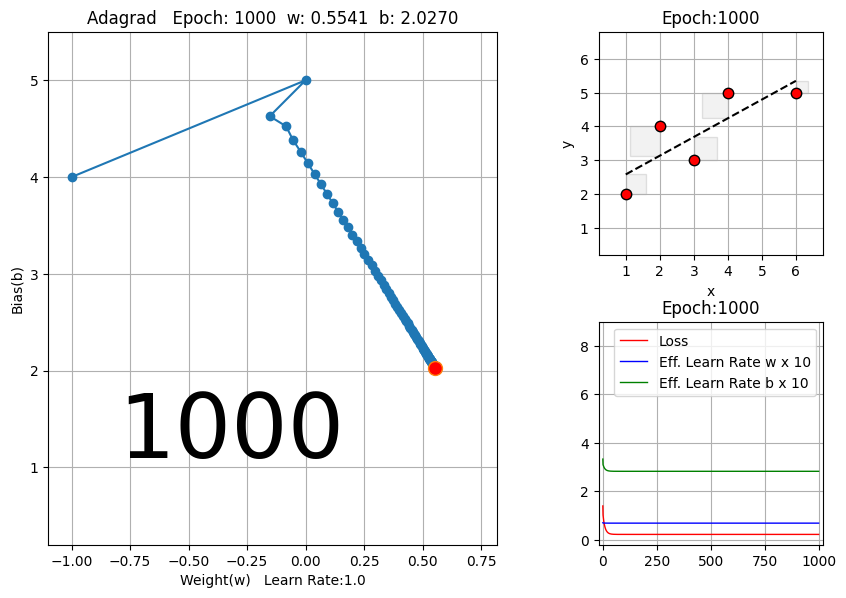

In [5]:
# Adagrad ------------------------------------------------ 4 <LinearRegOpt.ipynb>

LEARN_RATE =  1.0                                        # 학습율
MaxEpochs =  1000                                        # 반복 횟수

w = -1.0                                                 # 초기값 w
b = 4.0                                                  # 초기값 b

EPSILON = 1E-8
r_w = 0
r_b = 0

paths_w = [w,]
paths_b = [b,]
batch_loss = []
eff_learn_rate_w = []
eff_learn_rate_b = []

for epoch in range(MaxEpochs):                           # MaxEpochs번 반복

  grad_w, grad_b = loss_grad(w, b, x_train, y_train)     # 그래디언트 계산

  r_w = r_w + grad_w**2
  eff_lr_w = LEARN_RATE / (np.sqrt(r_w) + EPSILON)
  w = w - eff_lr_w * grad_w

  r_b = r_b + grad_b**2
  eff_lr_b = LEARN_RATE / (np.sqrt(r_b) + EPSILON)
  b = b - eff_lr_b * grad_b

  paths_w.append(w)
  paths_b.append(b)
  eff_learn_rate_w.append(eff_lr_w)
  eff_learn_rate_b.append(eff_lr_b)
  batch_loss.append(loss(w, b, x_train, y_train))

graph('Adagrad', epoch+1, w, b, LEARN_RATE, paths_w, paths_b, batch_loss,
      x_train, y_train, eff_learn_rate_w, eff_learn_rate_b)


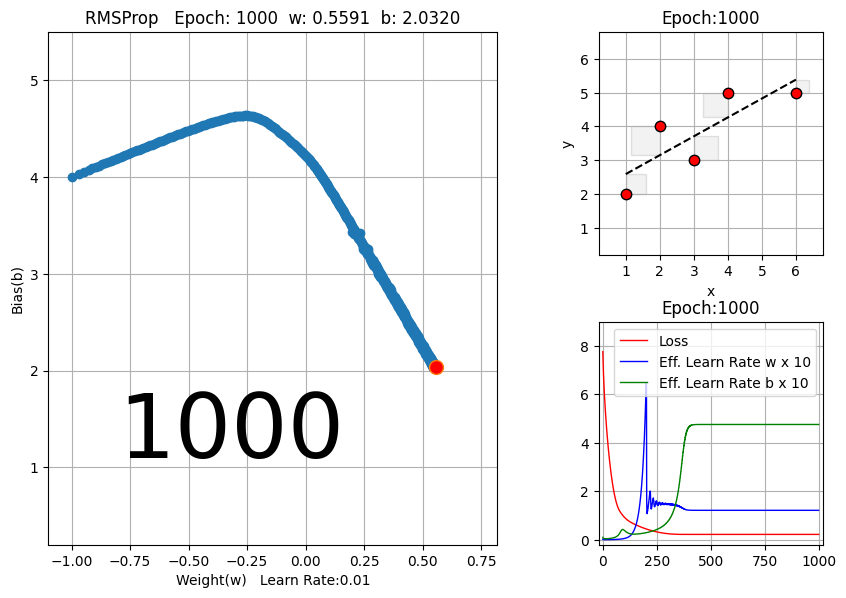

In [6]:
# RMSProp(Root Mean Square Propagation) ------------------ 5 <LinearRegOpt.ipynb>
#
LEARN_RATE = 0.01                                        # 학습율
MaxEpochs = 1000                                         # 반복 횟수

w = -1.0                                                 # 초기값 w
b = 4.0                                                  # 초기값 b

EPSILON = 1E-8
BETA = 0.9

m_w = 0
m_b = 0

paths_w = [w,]
paths_b = [b,]
batch_loss = []
eff_learn_rate_w = []
eff_learn_rate_b = []

for epoch in range(MaxEpochs):                           # MaxEpochs번 반복
  # 기울기 W, 절편 b 의 미분
  grad_w, grad_b = loss_grad(w, b, x_train, y_train)     # 그래디언트 계산
  # 기울기 w 에 대한 RMSProp
  m_w = BETA * m_w + (1. - BETA) * grad_w**2             # 모멘트
  eff_lr_w = LEARN_RATE / (np.sqrt(m_w) + EPSILON)       # 실제 적용 학습율
  w = w - eff_lr_w * grad_w                              # 파라메타 업데이트
  # 절편 b 에 대한 RMSProp
  m_b = BETA * m_b + (1. - BETA) * grad_b**2             # 모멘트
  eff_lr_b = LEARN_RATE / (np.sqrt(m_b) + EPSILON)       # 실제 적용 학습율
  b = b - eff_lr_b * grad_b                              # 파라메타 업데이트

  paths_w.append(w)
  paths_b.append(b)
  eff_learn_rate_w.append(eff_lr_w)
  eff_learn_rate_b.append(eff_lr_b)
  batch_loss.append(loss(w, b, x_train, y_train))

graph('RMSProp', epoch+1, w, b, LEARN_RATE, paths_w, paths_b, batch_loss,
      x_train, y_train, eff_learn_rate_w, eff_learn_rate_b)


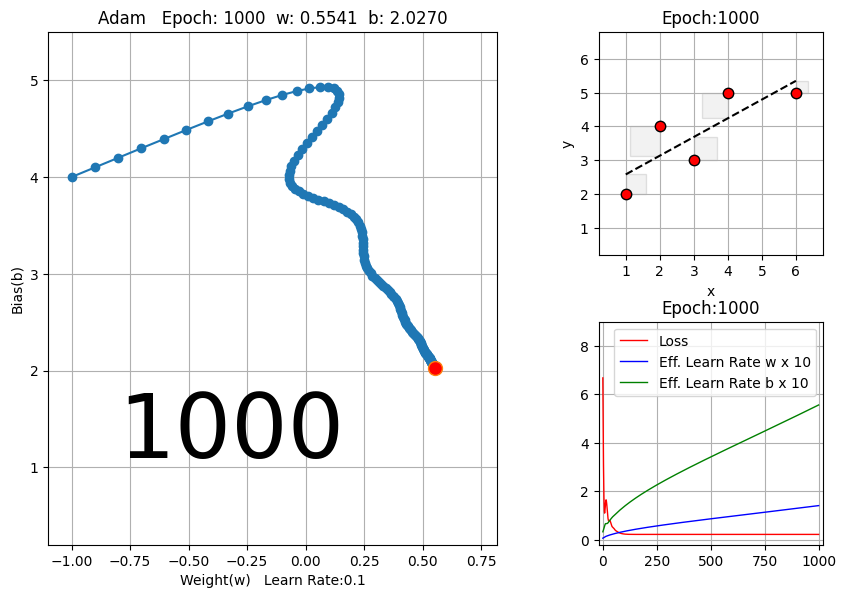

In [7]:
# Adam  -------------------------------------------------- 6 <LinearRegOpt.ipynb>

LEARN_RATE = 0.1                                       # 학습율
MaxEpochs = 1000                                       # 반복 횟수

w = -1.0                                               # 초기값 w
b = 4.0                                                # 초기값 b

EPSILON = 1E-8
BETA1 = 0.9
BETA2 = 0.999

m_w = 0
v_w = 0

m_b = 0
v_b = 0

t = 1

paths_w = [w,]
paths_b = [b,]
batch_loss = []
eff_learn_rate_w = []
eff_learn_rate_b = []

for epoch in range(MaxEpochs):                         # MaxEpochs 번 반복

  # 기울기 W, 절편 b 의 미분
  grad_w, grad_b = loss_grad(w, b, x_train, y_train)   # 그래디언트 계산
  # 기울기 w 에 대한 Adam
  m_w = BETA1 * m_w + (1. - BETA1) * grad_w            # 1 차 모멘트(최근 값을 많이 반영)
  v_w = BETA2 * v_w + (1. - BETA2) * grad_w**2         # 2 차 모멘트(과거 값을 많이 반영)
  hat_m_w = m_w / (1. - BETA1 ** t)                    # m 바이어스 보정
  hat_v_w = v_w / (1. - BETA2 ** t)                    # v 바이어스 보정
  eff_lr_w = LEARN_RATE / (np.sqrt(hat_v_w) + EPSILON) # 실제 적용 합습율
  w = w - eff_lr_w * hat_m_w                           # 파라미터 업데이트
  # 절편 b 에 대한 Adam
  m_b = BETA1 * m_b + (1. - BETA1) * grad_b            # 1 차 모멘트(최근 값을 많이 반영)
  v_b = BETA2 * v_b + (1. - BETA2) * grad_b**2         # 2 차 모멘트(과거 값을 많이 반영)
  hat_m_b = m_b / (1. - BETA1 ** t)                    # m 바이어스 보정
  hat_v_b = v_b / (1. - BETA2 ** t)                    # v 바이어스 보정
  eff_lr_b = LEARN_RATE / (np.sqrt(hat_v_b) + EPSILON) # 실제 적용 합습율
  b = b - eff_lr_b * hat_m_b                           # 파라미터 업데이트

  t = t + 1                                            # time step 증가

  paths_w.append(w)
  paths_b.append(b)
  batch_loss.append(loss(w, b, x_train, y_train))
  eff_learn_rate_w.append(eff_lr_w)
  eff_learn_rate_b.append(eff_lr_b)

graph('Adam', epoch+1, w, b, LEARN_RATE, paths_w, paths_b, batch_loss,
      x_train, y_train, eff_learn_rate_w, eff_learn_rate_b)


In [ ]:
import zipfile
import os

output_zip_filename = 'data.zip'

# Get a list of all .png files in the current directory
png_files = [f for f in os.listdir('.') if f.endswith('.png')]

if not png_files:
    print(f"No .png files found in the current directory.")
else:
    # Create a zip file and add the .png files
    with zipfile.ZipFile(output_zip_filename, 'w') as zipf:
        for png_file in png_files:
            zipf.write(png_file)
    print(f"Successfully created '{output_zip_filename}' containing {len(png_files)} .png files.")


Successfully created 'data.zip' containing 797 .png files.
